# 02 - The user-item graph

Questions for this notebook:

1. what does the training graph look like (degrees, connectivity),
2. is there a structural reason why message passing could hurt on this graph,
3. what do Node2Vec's p/q parameters do on a bipartite graph,
4. do the learned item embeddings encode anything interpretable (genres).

The graph is built from the training positives only (`src/recsysx/graph/build.py`): users and movies are nodes, an undirected edge means "rated 4 or 5 before the cutoff".

In [1]:
import json
import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
from IPython.display import Image, display

from recsysx.config import load_config
from recsysx.data import RecData
from recsysx.graph import graph_stats

cfg = load_config()
data = RecData.load(cfg)
stats = graph_stats(data.train_pos, data.n_users, data.n_items)
pd.json_normalize(stats).T.rename(columns={0: "value"})

,value
n_user_nodes,6040.000000
n_item_nodes,3706.000000
n_nodes,9746.000000
n_edges,463017.000000
bipartite_density,0.020685
avg_degree_all,95.016830
isolated_users,644.000000
isolated_items,237.000000
users_degree_le_5,62.000000
items_degree_le_5,553.000000


About 463k edges between 9.7k nodes. Apart from the isolated nodes (users who only appear after the cutoff and movies with no training positive) everything is one connected component. The last block is the interesting one: a typical user shares at least one liked movie with almost every other user that has a training history.

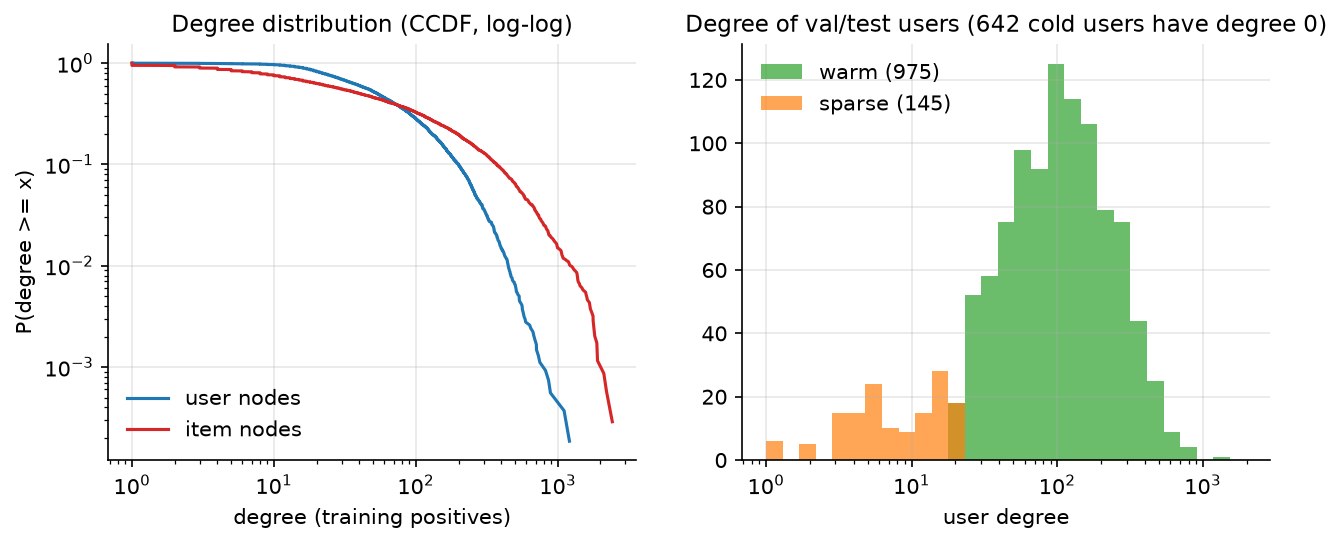

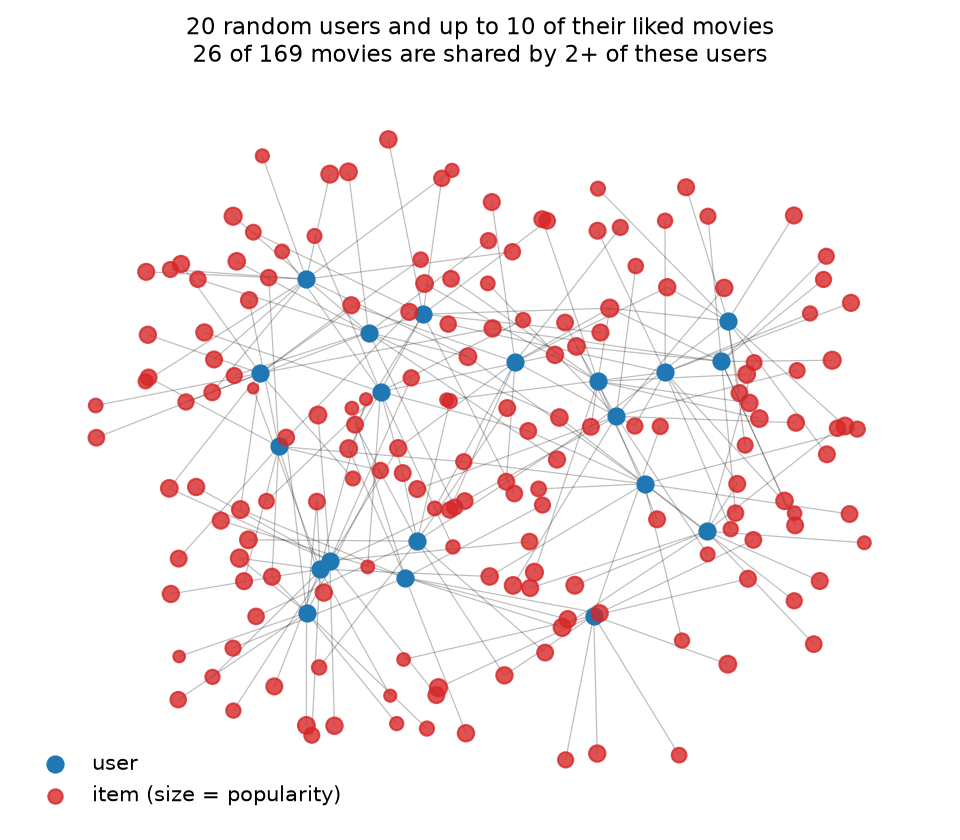

In [2]:
display(Image("../results/figures/graph_degree_distribution.png"))
display(Image("../results/figures/graph_sampled_subgraph.png"))

## Over-smoothing check

GraphSAGE with mean aggregation replaces a node by (a transform of) the average of its neighbours. If every user is two hops away from almost every other user through the same blockbusters, repeated averaging should make all user representations look alike.

A cheap way to see this without any training: give every movie its genre vector, then propagate with plain mean aggregation over the bipartite graph and measure how similar the user representations are to each other after each step.

In [3]:
R = data.train_matrix().astype(np.float64)               # users x items
known = np.where(np.diff(R.indptr) > 0)[0]
deg_u = np.asarray(R.sum(1)).ravel()
deg_i = np.asarray(R.sum(0)).ravel()
P_user = sp.diags(1 / np.maximum(deg_u, 1)) @ R          # user <- mean of its items
P_item = sp.diags(1 / np.maximum(deg_i, 1)) @ R.T        # item <- mean of its users
rng = np.random.default_rng(0)
sample = rng.choice(known, 1000, replace=False)

def mean_pairwise_cos(X):
    X = X / np.linalg.norm(X, axis=1, keepdims=True).clip(1e-12)
    S = X @ X.T
    return (S.sum() - len(X)) / (len(X) * (len(X) - 1))

x_item = data.genre_matrix().astype(np.float64)
rows = []
for hop in range(1, 6, 2):          # users after 1, 3, 5 propagation steps
    x_user = P_user @ x_item
    rows.append({"user layer (hops)": hop, "mean pairwise cosine between users": mean_pairwise_cos(x_user[sample])})
    x_item = P_item @ x_user        # items take the mean of their users for the next round
pd.DataFrame(rows)

,user layer (hops),mean pairwise cosine between users
0,1,0.711671
1,3,0.986109
2,5,0.999140


In [4]:
# for reference: how similar are two random movies' genre vectors, and the users' raw genre profiles
print("random movies:", round(mean_pairwise_cos(data.genre_matrix()[rng.choice(data.n_items, 1000, replace=False)]), 3))

random movies: 0.221


After one step (each user = the average genre vector of what they liked) users are already quite similar to each other, and after three steps they are almost indistinguishable. Learned GNN layers can partly counter this (they have a separate weight for the node itself), but it shows how little room there is: the neighbourhood average of an average user on MovieLens is "a bit of Drama, Comedy, Action, Thriller". This fits what the experiments showed: 1-layer GraphSAGE beat 2 layers, and the propagation that worked (LightGCN) keeps the layer-0 embedding in the final average.

## Node2Vec p/q on a bipartite graph

Node2Vec biases the walk with p (return) and q (in-out). After a step t -> v, the next node x is weighted 1/p if x = t, 1 if x is a neighbour of t, 1/q otherwise. In a bipartite graph t and x are always on the same side, so x can never be a neighbour of t. Only the ratio between "go back" (1/p) and "go anywhere else" (1/q) matters. Checking the actual share of immediate returns:

In [5]:
from torch_cluster import random_walk
from recsysx.graph import edge_index

ei = edge_index(data.train_pos, data.n_users)
row, col = ei
start = torch.as_tensor(rng.choice(known, 2000, replace=False))
for p, q in [(1.0, 1.0), (4.0, 1.0), (0.25, 1.0), (1.0, 4.0)]:
    walks = random_walk(row, col, start, walk_length=20, p=p, q=q, num_nodes=data.n_users + data.n_items)
    back = (walks[:, 2:] == walks[:, :-2]).float().mean().item()
    print(f"p={p:<5} q={q:<4} share of steps that go straight back: {back:.3f}")

p=1.0   q=1.0  share of steps that go straight back: 0.010
p=4.0   q=1.0  share of steps that go straight back: 0.009
p=0.25  q=1.0  share of steps that go straight back: 0.032
p=1.0   q=4.0  share of steps that go straight back: 0.034


p = 1, q = 4 behaves almost like p = 0.25, q = 1, as expected from the ratio argument. Most nodes have high degree, so even with p = 1 a walk rarely steps straight back (about 1% of the steps), and p = 4 can hardly reduce that further. The validation results of the p/q stage of the tuning agree: the differences are tiny.

In [6]:
tun = pd.read_csv("../results/tables/tuning_results.csv")
tun[tun["tuned_model"] == "node2vec"][["run", "stage", "val/recall@20", "best_epoch", "train_time_s"]].round(4)

,run,stage,val/recall@20,best_epoch,train_time_s
28,node2vec__default,1,0.1017,19.0,33.2998
29,"node2vec__p=1.0,q=1.0",1,0.1017,19.0,28.1340
30,"node2vec__p=0.25,q=1.0",1,0.1027,20.0,118.2512
31,"node2vec__p=4.0,q=1.0",1,0.1025,21.0,53.4869
32,"node2vec__context_size=10,p=0.25,q=1.0,walk_le...",2,0.1006,19.0,114.3202
33,"node2vec__context_size=5,p=0.25,q=1.0",2,0.1058,29.0,141.3043
34,"node2vec__context_size=5,p=0.25,q=1.0,score=co...",3,0.0568,11.0,64.7953
35,"node2vec__context_size=5,p=0.25,q=1.0,score=ha...",3,0.1015,18.0,104.9956


## What the item embeddings learned

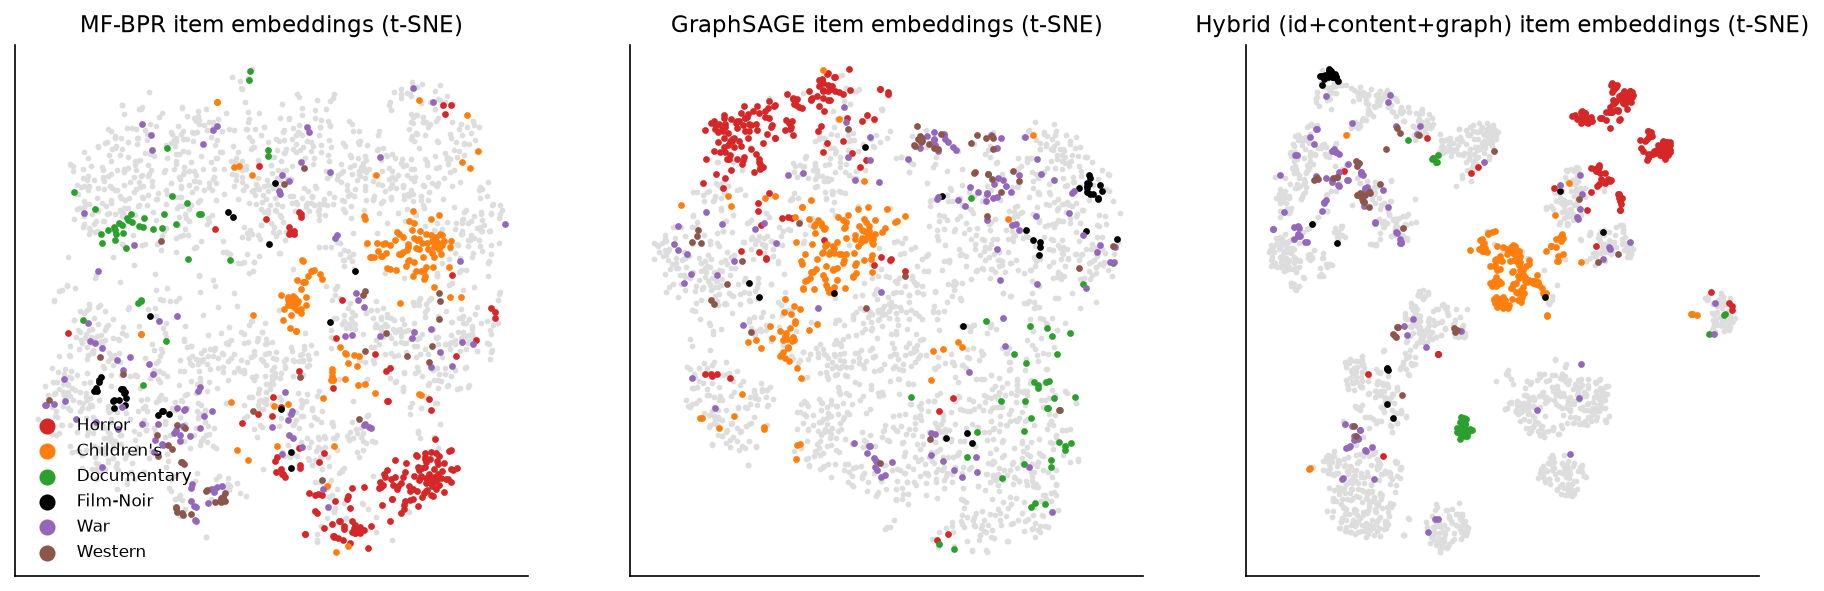

,model,nn10_share_sharing_a_genre,random_baseline,items
0,MF-BPR,0.825488,0.356871,2205
1,Two-Tower,0.923356,0.356871,2205
2,Node2Vec,0.883719,0.356871,2205
3,GraphSAGE,0.822404,0.356871,2205
4,GAT,0.880544,0.356871,2205
5,LightGCN,0.879002,0.356871,2205
6,Hybrid (id+content+graph),0.973787,0.356871,2205


In [7]:
display(Image("../results/figures/embedding_tsne.png"))
pd.read_csv("../results/tables/embedding_genre_purity.csv")

`nn10_share_sharing_a_genre`: for each movie with at least 20 training positives, the share of its 10 nearest neighbours (cosine) that share at least one genre with it. Random pairs give the baseline. The two-tower model has genres as an *input* of the item tower, so its high number is partly by construction. For the purely collaborative models it is a fair check of whether co-liking structure lines up with genres.

## Where does GraphSAGE lose against MF?

In [8]:
tab = pd.read_csv("../results/tables/error_graph_neighbourhood.csv")
corr = json.load(open("../results/tables/error_graph_neighbourhood_corr.json"))
display(tab)
corr

,neighbour_degree_quartile,users,mean_item_degree,recall_graph,recall_mf,mean_diff
0,Q1 (nichest),140,409.200697,0.081465,0.087476,-0.006011
1,Q2,140,552.531694,0.109124,0.116764,-0.007639
2,Q3,140,662.456169,0.109028,0.128513,-0.019485
3,Q4 (most popular),140,884.716585,0.147218,0.139796,0.007421


{'spearman_diff_vs_mean_item_degree': -0.012841610996608256,
 'p_value': 0.761721091930253,
 'spearman_diff_vs_user_degree': -0.00313251313666415,
 'p_value_user_degree': 0.9410395591441356,
 'n_users': 560}

Users are split by the average degree of the movies they liked (Q1 = their movies are relatively niche, Q4 = they mostly liked blockbusters). `mean_diff` is GraphSAGE minus MF recall@20 on the test users. The Spearman correlation between this difference and the users' average item degree says whether "being connected through very popular items" is where GraphSAGE loses ground. See the report (error analysis) for the interpretation of the actual numbers.